# Foundations Deep Dive (Intro to Gen AI, Note 01)

Companion notebook for `01-AI-ML-DL-Foundations.md`. It turns the theory of the note into experiments. Only NumPy, SciPy, matplotlib and scikit-learn are needed.

| Part | Topic |
|---|---|
| A | Empirical risk vs true risk: the gap shrinks like 1/√n (with the Hoeffding bound) |
| B | Mean minimises MSE, median minimises MAE (numerically) |
| C | Cross-entropy = negative log-likelihood; the worked examples of the note |
| D | Bayes' rule and Naive Bayes by hand, checked against scikit-learn |
| E | Gaussian Naive Bayes (generative) vs logistic regression (discriminative) |
| F | Generative sampling from fitted Gaussian class-conditional models |
| G | Learning curves and the generalisation gap |
| H | Bias–variance decomposition by simulation |
| I | Hoeffding / union-bound sample-size calculator |
| J | Checks for the note's worked examples and practice problems (ERM by hand, Bayes-optimal threshold, bias–variance shrinkage) |


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## Part A — Empirical risk vs true risk

Fix one hypothesis *before* looking at data: the threshold classifier `h(x) = 1[x > 0]`. Data: `X ~ N(0,1)`, `Y = 1[X + 0.5·noise > 0]`. The true risk `R(h) = P(h(X) ≠ Y)` is estimated once with 2 million samples. Then, for each sample size n, draw many training sets, compute the empirical risk, and measure how far it is from the truth. Hoeffding says `P(|R̂ − R| > ε) ≤ 2 exp(−2nε²)`.

In [2]:
def sample(n, rng):
    x = rng.normal(size=n)
    y = (x + 0.5 * rng.normal(size=n) > 0).astype(int)
    return x, y

h = lambda x: (x > 0).astype(int)
xb, yb = sample(2_000_000, rng)
R_true = np.mean(h(xb) != yb)
print(f"true risk R(h) ≈ {R_true:.4f}   (exact: arctan(0.5)/π = {math.atan(0.5)/math.pi:.4f})")

eps = 0.05
ns = [10, 30, 100, 300, 1000, 3000]
print(f"{'n':>6} {'mean|R̂−R|':>11} {'P(|R̂−R|>0.05)':>15} {'Hoeffding bound':>16}")
for n in ns:
    gaps = []
    for _ in range(2000):
        x, y = sample(n, rng)
        gaps.append(abs(np.mean(h(x) != y) - R_true))
    gaps = np.array(gaps)
    print(f"{n:>6} {gaps.mean():>11.4f} {np.mean(gaps > eps):>15.3f} {min(1, 2*np.exp(-2*n*eps**2)):>16.3f}")

true risk R(h) ≈ 0.1476   (exact: arctan(0.5)/π = 0.1476)
     n  mean|R̂−R|  P(|R̂−R|>0.05)  Hoeffding bound
    10      0.0925           0.639            1.000
    30      0.0522           0.438            1.000
   100      0.0278           0.143            1.000
   300      0.0165           0.013            0.446


  1000      0.0087           0.000            0.013


  3000      0.0051           0.000            0.000


The average gap falls roughly like 1/√n (10× more data → about 3.2× smaller gap), and the observed tail probability always sits below the Hoeffding bound. The bound is loose for small n but needs no assumption on the distribution beyond a loss in [0, 1].

## Part B — The mean minimises MSE, the median minimises MAE

Predict a single constant `c` for skewed data (exponential, like incomes or house prices). Scan `c` over a grid.

c=3:  MSE=59.0   MAE=4.2
c=6:  MSE=50.0   MAE=5.6
sample mean   = 10.164   argmin MSE = 10.160
sample median = 6.860   argmin MAE = 6.860


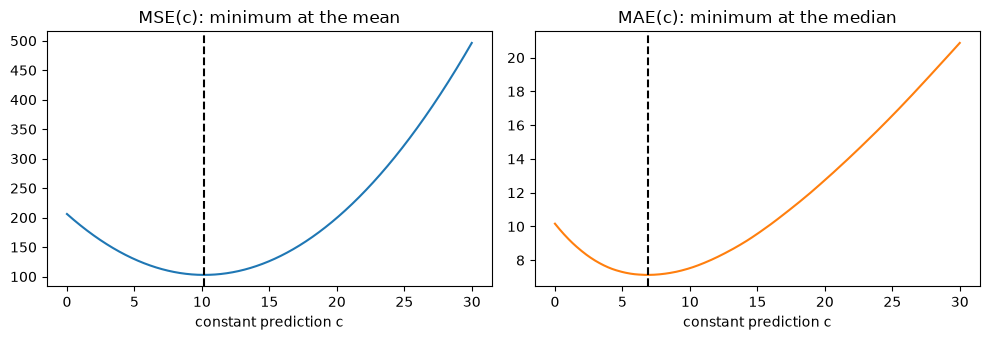

In [3]:
d = np.array([1, 2, 3, 4, 20.])          # the note's worked example
for c in [3, 6]:
    print(f"c={c}:  MSE={np.mean((d-c)**2):.1f}   MAE={np.mean(np.abs(d-c)):.1f}")

data = rng.exponential(scale=10, size=1001)
cs = np.linspace(0, 30, 3001)
mse = ((data[None, :] - cs[:, None])**2).mean(1)
mae = np.abs(data[None, :] - cs[:, None]).mean(1)
print(f"sample mean   = {data.mean():.3f}   argmin MSE = {cs[mse.argmin()]:.3f}")
print(f"sample median = {np.median(data):.3f}   argmin MAE = {cs[mae.argmin()]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(cs, mse); ax[0].axvline(data.mean(), ls='--', c='k'); ax[0].set_title('MSE(c): minimum at the mean')
ax[1].plot(cs, mae, c='C1'); ax[1].axvline(np.median(data), ls='--', c='k'); ax[1].set_title('MAE(c): minimum at the median')
for a in ax: a.set_xlabel('constant prediction c')
plt.tight_layout(); plt.show()

Add an outlier and watch which minimiser moves:

In [4]:
d2 = np.append(data, 10_000)
print(f"mean:   {data.mean():.2f} -> {d2.mean():.2f}")
print(f"median: {np.median(data):.2f} -> {np.median(d2):.2f}")

mean:   10.16 -> 20.13
median: 6.86 -> 6.86


## Part C — Cross-entropy is the negative log-likelihood

For Bernoulli labels the likelihood of predicted probabilities `p` is `∏ p^y (1−p)^(1−y)`. Its negative log divided by n is exactly binary cross-entropy (log loss).

In [5]:
from sklearn.metrics import log_loss
y = np.array([1, 0, 1, 1, 0, 1]); p = np.array([.8, .4, .3, .9, .6, .7])
per = -(y*np.log(p) + (1-y)*np.log(1-p))
print("per-example losses:", per.round(4))
print(f"mean BCE (by hand) = {per.mean():.4f}   sklearn log_loss = {log_loss(y, p):.4f}")
lik = np.prod(p**y * (1-p)**(1-y))
print(f"likelihood = {lik:.6f}   -log(lik)/n = {-np.log(lik)/len(y):.4f}")
print(f"0-1 risk at threshold 0.5 = {np.mean((p >= .5).astype(int) != y):.4f}")

# The constant p that minimises BCE is the fraction of positives (the MLE)
ps = np.linspace(0.01, 0.99, 981)
bce = [-(y*np.log(q) + (1-y)*np.log(1-q)).mean() for q in ps]
print(f"argmin_p BCE = {ps[np.argmin(bce)]:.3f}   fraction of 1s = {y.mean():.3f}")

per-example losses: [0.2231 0.5108 1.204  0.1054 0.9163 0.3567]
mean BCE (by hand) = 0.5527   sklearn log_loss = 0.5527
likelihood = 0.036288   -log(lik)/n = 0.5527
0-1 risk at threshold 0.5 = 0.3333
argmin_p BCE = 0.667   fraction of 1s = 0.667


## Part D — Bayes' rule and Naive Bayes by hand

Spam example: P(spam) = 0.2, P("free" | spam) = 0.6, P("free" | ham) = 0.05.

In [6]:
p_s, p_f_s, p_f_h = 0.2, 0.6, 0.05
post = p_s*p_f_s / (p_s*p_f_s + (1-p_s)*p_f_h)
print(f"P(spam | 'free') = {post:.4f}")

P(spam | 'free') = 0.7500


Tiny dataset of 8 e-mails with two binary features: contains "free" (F), contains "meeting" (M). Laplace smoothing α = 1.

In [7]:
from sklearn.naive_bayes import BernoulliNB
X = np.array([[1,0],[1,0],[0,0],            # spam
              [0,1],[0,1],[1,1],[0,0],[0,1]])  # ham
y = np.array([1,1,1,0,0,0,0,0])

def nb_by_hand(x, alpha=1.0):
    scores = {}
    for c in [1, 0]:
        Xc = X[y == c]; prior = len(Xc) / len(X)
        theta = (Xc.sum(0) + alpha) / (len(Xc) + 2*alpha)   # P(feature=1 | class)
        lik = np.prod(np.where(x == 1, theta, 1 - theta))
        scores[c] = prior * lik
        print(f"class {c}: prior={prior:.3f}  theta={theta.round(4)}  prior*lik={scores[c]:.5f}")
    return scores[1] / (scores[1] + scores[0])

for x in [np.array([1, 1]), np.array([1, 0])]:
    print(f"x={x}:  P(spam|x) by hand = {nb_by_hand(x):.4f}")
    print()

clf = BernoulliNB(alpha=1.0).fit(X, y)
print("sklearn BernoulliNB P(spam|x):", clf.predict_proba([[1,1],[1,0]])[:, 1].round(4))
print("without smoothing, P(M=1|spam) =", X[y==1, 1].mean(), "-> any e-mail with 'meeting' gets P(spam)=0")

class 1: prior=0.375  theta=[0.6 0.2]  prior*lik=0.04500
class 0: prior=0.625  theta=[0.2857 0.7143]  prior*lik=0.12755
x=[1 1]:  P(spam|x) by hand = 0.2608

class 1: prior=0.375  theta=[0.6 0.2]  prior*lik=0.18000
class 0: prior=0.625  theta=[0.2857 0.7143]  prior*lik=0.05102
x=[1 0]:  P(spam|x) by hand = 0.7792

sklearn BernoulliNB P(spam|x): [0.2608 0.7792]
without smoothing, P(M=1|spam) = 0.0 -> any e-mail with 'meeting' gets P(spam)=0


## Part E — Gaussian Naive Bayes (generative) vs logistic regression (discriminative)

Breast-cancer dataset (569 tumours, 30 features). Train both on growing training sets and compare test accuracy, averaged over 50 random splits. Ng & Jordan (2002) predicted: the generative model reaches its (higher) asymptotic error faster; the discriminative model has lower asymptotic error.

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

Xbc, ybc = load_breast_cancer(return_X_y=True)
sizes = [10, 20, 40, 80, 160, 320]
res = {"GaussianNB": [], "LogReg": []}
for m in sizes:
    acc_nb, acc_lr = [], []
    for seed in range(50):
        Xtr, Xte, ytr, yte = train_test_split(Xbc, ybc, train_size=m, test_size=200, stratify=ybc, random_state=seed)
        acc_nb.append(GaussianNB().fit(Xtr, ytr).score(Xte, yte))
        lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
        acc_lr.append(lr.fit(Xtr, ytr).score(Xte, yte))
    res["GaussianNB"].append(np.mean(acc_nb)); res["LogReg"].append(np.mean(acc_lr))
print(f"{'n_train':>8} {'GaussianNB':>11} {'LogReg':>8}")
for i, m in enumerate(sizes):
    print(f"{m:>8} {res['GaussianNB'][i]:>11.4f} {res['LogReg'][i]:>8.4f}")

 n_train  GaussianNB   LogReg
      10      0.9102   0.9054
      20      0.9295   0.9257
      40      0.9385   0.9510
      80      0.9383   0.9635
     160      0.9361   0.9682
     320      0.9357   0.9758


## Part F — A generative model can *sample* new data

Fit one Gaussian per class (full covariance, i.e. QDA's model of P(x | y)) to two Iris features, then sample brand-new flowers: first y ~ P(y), then x ~ P(x | y). A discriminative model like logistic regression cannot do this: it never models P(x).

class setosa      prior=0.333  mean=[1.462 0.246]
class versicolor  prior=0.333  mean=[4.26  1.326]
class virginica   prior=0.333  mean=[5.552 2.026]
training accuracy of the generative classifier: 0.9800


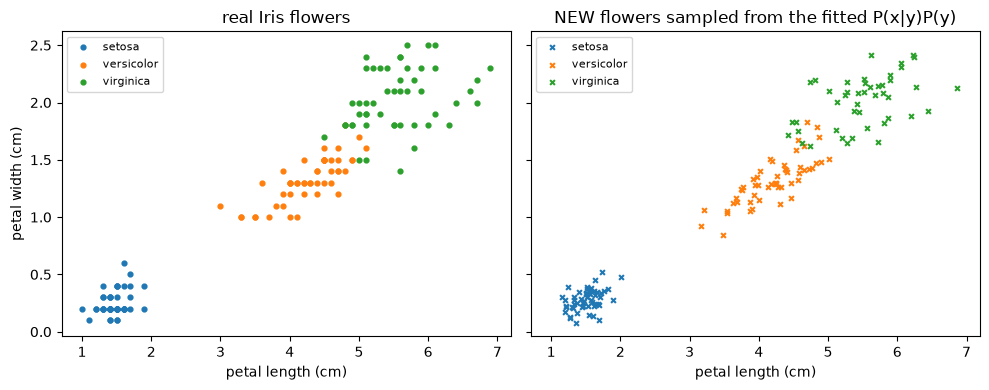

In [9]:
from sklearn.datasets import load_iris
iris = load_iris(); Xi = iris.data[:, [2, 3]]; yi = iris.target   # petal length, petal width
classes = np.unique(yi)
priors = np.array([np.mean(yi == k) for k in classes])
mus = [Xi[yi == k].mean(0) for k in classes]
covs = [np.cov(Xi[yi == k].T) for k in classes]
for k in classes:
    print(f"class {iris.target_names[k]:<11} prior={priors[k]:.3f}  mean={mus[k].round(3)}")

n_new = 150
ks = rng.choice(classes, size=n_new, p=priors)
X_new = np.array([rng.multivariate_normal(mus[k], covs[k]) for k in ks])

# The same model also classifies, via Bayes' rule
def predict(Xq):
    logp = np.column_stack([np.log(priors[k]) + stats.multivariate_normal(mus[k], covs[k]).logpdf(Xq) for k in classes])
    return logp.argmax(1)
print(f"training accuracy of the generative classifier: {np.mean(predict(Xi) == yi):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for k in classes:
    ax[0].scatter(*Xi[yi == k].T, s=12, label=iris.target_names[k])
    ax[1].scatter(*X_new[ks == k].T, s=12, marker='x', label=iris.target_names[k])
ax[0].set_title('real Iris flowers'); ax[1].set_title('NEW flowers sampled from the fitted P(x|y)P(y)')
for a in ax: a.set_xlabel('petal length (cm)'); a.legend(fontsize=8)
ax[0].set_ylabel('petal width (cm)')
plt.tight_layout(); plt.show()

## Part G — Learning curves and the generalisation gap

Polynomial regression on `y = sin(2πx) + noise` with degree 1 (too simple), 3 (about right) and 12 (too flexible). For each training size, average training and test MSE over 100 repetitions.

degree  1: n=15: train=0.236 test=0.329  n=50: train=0.282 test=0.303  n=500: train=0.285 test=0.294


degree  3: n=15: train=0.061 test=0.126  n=50: train=0.083 test=0.100  n=500: train=0.093 test=0.094


degree 12: n=15: train=0.034 test=4.444  n=50: train=0.073 test=0.114  n=500: train=0.088 test=0.091
noise variance (irreducible error) = 0.09


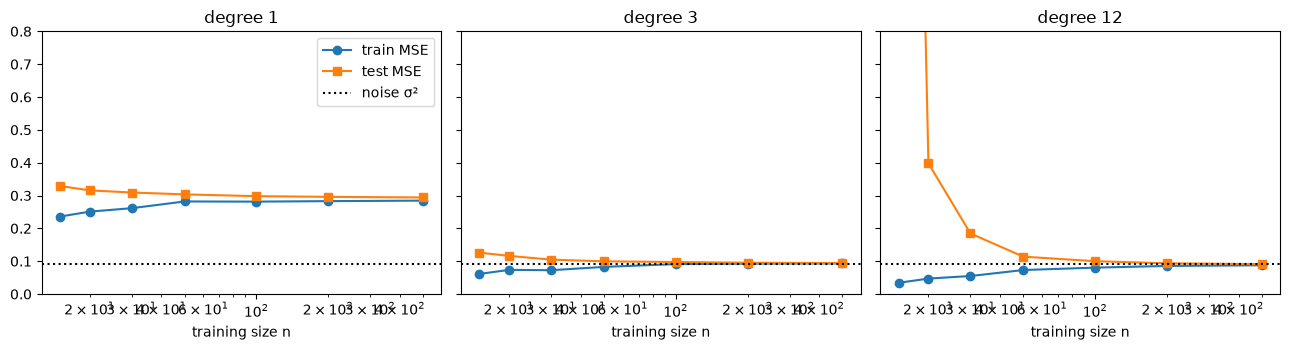

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def make(n, rng):
    x = rng.uniform(0, 1, n); return x[:, None], np.sin(2*np.pi*x) + rng.normal(0, 0.3, n)

Xtest, ytest = make(5000, rng)
sizes = [15, 20, 30, 50, 100, 200, 500]
curves = {}
for deg in [1, 3, 12]:
    tr, te = [], []
    for n in sizes:
        a, b = [], []
        for _ in range(100):
            Xt, yt = make(n, rng)
            m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(Xt, yt)
            a.append(np.mean((m.predict(Xt) - yt)**2)); b.append(np.mean((m.predict(Xtest) - ytest)**2))
        tr.append(np.median(a)); te.append(np.median(b))
    curves[deg] = (tr, te)
    print(f"degree {deg:>2}: " + "  ".join(f"n={n}: train={x:.3f} test={z:.3f}" for n, x, z in zip(sizes, tr, te) if n in (15, 50, 500)))
print("noise variance (irreducible error) = 0.09")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for a, deg in zip(ax, [1, 3, 12]):
    tr, te = curves[deg]
    a.plot(sizes, tr, 'o-', label='train MSE'); a.plot(sizes, te, 's-', label='test MSE')
    a.axhline(0.09, ls=':', c='k', label='noise σ²'); a.set_xscale('log'); a.set_ylim(0, 0.8)
    a.set_title(f'degree {deg}'); a.set_xlabel('training size n')
ax[0].legend(); plt.tight_layout(); plt.show()

Reading the curves: degree 1 has a small gap but both errors stay high (**bias**). Degree 12 has a huge gap for small n (**variance / over-fitting**) that closes as n grows. More data fixes variance, not bias.

## Part H — Bias–variance decomposition by simulation

At a fixed test point x₀ = 0.25 (true value sin(π/2) = 1), refit each model on 500 fresh training sets of size 30 and decompose the expected squared error into bias² + variance + noise.

In [11]:
x0 = np.array([[0.25]]); f0 = np.sin(2*np.pi*0.25); sigma2 = 0.09
print(f"{'degree':>6} {'bias^2':>8} {'variance':>9} {'noise':>6} {'sum':>7} {'MC E[(y-ŷ)^2]':>15}")
for deg in [1, 3, 5, 9, 12]:
    preds = []
    for _ in range(500):
        Xt, yt = make(30, rng)
        preds.append(make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(Xt, yt).predict(x0)[0])
    preds = np.array(preds)
    b2, var = (preds.mean() - f0)**2, preds.var()
    y0 = f0 + rng.normal(0, 0.3, preds.size)
    print(f"{deg:>6} {b2:>8.4f} {var:>9.4f} {sigma2:>6.2f} {b2+var+sigma2:>7.4f} {np.mean((y0-preds)**2):>15.4f}")

degree   bias^2  variance  noise     sum   MC E[(y-ŷ)^2]


     1   0.2568    0.0199   0.09  0.3667          0.3774


     3   0.0003    0.0105   0.09  0.1008          0.1075


     5   0.0001    0.0170   0.09  0.1071          0.1006


     9   0.0000    0.0302   0.09  0.1202          0.1131


    12   0.0000    0.0301   0.09  0.1201          0.1183


Shrinkage example from the note: estimating μ with λ·x̄ where μ = 1, σ² = 4, n = 4.

In [12]:
mu, s2, n = 1.0, 4.0, 4
for lam in [1.0, 0.5]:
    est = lam * rng.normal(mu, np.sqrt(s2), size=(200_000, n)).mean(1)
    print(f"λ={lam}: theory bias²={(lam-1)**2*mu**2:.3f} var={lam**2*s2/n:.3f} MSE={(lam-1)**2*mu**2+lam**2*s2/n:.3f}   simulated MSE={np.mean((est-mu)**2):.3f}")

λ=1.0: theory bias²=0.000 var=1.000 MSE=1.000   simulated MSE=0.998
λ=0.5: theory bias²=0.250 var=0.250 MSE=0.500   simulated MSE=0.499


## Part I — How many samples? Hoeffding and the union bound

Single fixed hypothesis: `n ≥ ln(2/δ) / (2ε²)`. Finite class ℋ (any h, including the ERM choice): `n ≥ (ln|ℋ| + ln(2/δ)) / (2ε²)`.

In [13]:
def n_single(eps, delta): return math.ceil(math.log(2/delta) / (2*eps**2))
def n_class(eps, delta, H): return math.ceil((math.log(H) + math.log(2/delta)) / (2*eps**2))
def eps_class(n, delta, H): return math.sqrt((math.log(H) + math.log(2/delta)) / (2*n))

print("single h, ε=0.05, δ=0.05:", n_single(0.05, 0.05))
print("|H|=1000, ε=0.05, δ=0.05:", n_class(0.05, 0.05, 1000))
print("single h, ε=0.02, δ=0.01:", n_single(0.02, 0.01))
print(f"|H|=2^20, n=10000, δ=0.05: ε = {eps_class(10_000, 0.05, 2**20):.4f}")
for H in [1, 10, 1e3, 1e6, 1e9]:
    print(f"|H|={H:>8.0e}: n needed for ε=0.05, δ=0.05 -> {n_class(0.05, 0.05, H)}")

single h, ε=0.05, δ=0.05: 738
|H|=1000, ε=0.05, δ=0.05: 2120
single h, ε=0.02, δ=0.01: 6623
|H|=2^20, n=10000, δ=0.05: ε = 0.0296
|H|=   1e+00: n needed for ε=0.05, δ=0.05 -> 738
|H|=   1e+01: n needed for ε=0.05, δ=0.05 -> 1199
|H|=   1e+03: n needed for ε=0.05, δ=0.05 -> 2120
|H|=   1e+06: n needed for ε=0.05, δ=0.05 -> 3501
|H|=   1e+09: n needed for ε=0.05, δ=0.05 -> 4883


The sample size grows only **logarithmically** with the size of the hypothesis class: a billion hypotheses need about 5.6× the data of a single one, not a billion times more.

## Part J — Checking the note's worked examples

Every number in the worked examples and practice problems of the note is recomputed here.

In [14]:
# Empirical risk of two regression hypotheses under squared and absolute loss
x = np.array([1, 2, 3, 4.]); y = np.array([3, 5, 6, 10.])
for name, pred in [("h1(x)=2x+1", 2*x + 1), ("h2(x)=2.5x", 2.5*x)]:
    r = pred - y
    print(f"{name}: residuals={r}  L_sq={np.mean(r**2):.4f}  L_abs={np.mean(np.abs(r)):.4f}")

# ERM over a finite class of threshold classifiers under 0-1 loss
xc = np.array([0.5, 1.2, 2.0, 2.7, 3.1, 3.8]); yc = np.array([0, 0, 1, 0, 1, 1])
for t in [1.0, 1.5, 2.9]:
    print(f"threshold t={t}: empirical 0-1 risk = {np.mean((xc > t).astype(int) != yc):.4f}")

# Base-rate example: prevalence 1%, sensitivity 0.99, specificity 0.95
print(f"P(disease | +) = {0.01*0.99 / (0.01*0.99 + 0.99*0.05):.4f}")

# Bayes-optimal threshold for N(0,1) (class 0) vs N(2,1) (class 1)
for p1 in [0.5, 0.8]:
    p0 = 1 - p1
    t = 1 - math.log(p1/p0)/2
    err = p0*(1 - stats.norm.cdf(t)) + p1*stats.norm.cdf(t - 2)
    print(f"P(y=1)={p1}: Bayes threshold t*={t:.4f}, Bayes error={err:.4f}")

# Shrinkage estimator lambda*xbar: MSE(lambda) = (lambda-1)^2 mu^2 + lambda^2 sigma^2/n
for mu, s2, n in [(1, 4, 4), (2, 9, 9)]:
    lam_star = mu**2 / (mu**2 + s2/n)
    print(f"mu={mu}, sigma^2={s2}, n={n}: lambda*={lam_star:.3f}, MSE(lambda*)={(lam_star-1)**2*mu**2 + lam_star**2*s2/n:.3f}, MSE(1)={s2/n:.3f}")

# Cross-entropy / perplexity
print(f"-ln 0.9={-math.log(.9):.4f}  -ln 0.5={-math.log(.5):.4f}  -ln 0.1={-math.log(.1):.4f}  -ln 0.01={-math.log(.01):.4f}")
print(f"uniform over 50,257 tokens: CE = ln V = {math.log(50257):.4f} nats; CE 2.0 nats -> perplexity {math.exp(2):.3f}")

h1(x)=2x+1: residuals=[ 0.  0.  1. -1.]  L_sq=0.5000  L_abs=0.5000
h2(x)=2.5x: residuals=[-0.5  0.   1.5  0. ]  L_sq=0.6250  L_abs=0.5000
threshold t=1.0: empirical 0-1 risk = 0.3333
threshold t=1.5: empirical 0-1 risk = 0.1667
threshold t=2.9: empirical 0-1 risk = 0.1667
P(disease | +) = 0.1667
P(y=1)=0.5: Bayes threshold t*=1.0000, Bayes error=0.1587
P(y=1)=0.8: Bayes threshold t*=0.3069, Bayes error=0.1121
mu=1, sigma^2=4, n=4: lambda*=0.500, MSE(lambda*)=0.500, MSE(1)=1.000
mu=2, sigma^2=9, n=9: lambda*=0.800, MSE(lambda*)=0.800, MSE(1)=1.000
-ln 0.9=0.1054  -ln 0.5=0.6931  -ln 0.1=2.3026  -ln 0.01=4.6052
uniform over 50,257 tokens: CE = ln V = 10.8249 nats; CE 2.0 nats -> perplexity 7.389
